## Linear regression

The handout uses materials from [here](https://www.geeksforgeeks.org/machine-learning/ml-linear-regression/), [here](https://www.w3schools.com/python/python_ml_linear_regression.asp), [here](https://towardsdatascience.com/linear-regression-using-python-b136c91bf0a2), and [here](https://github.com/esokolov/ml-course-hse/blob/master/2021-fall/seminars/sem02-sklearn-linregr.ipynb).

#### A simple example

In [1]:
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
x = [5,7,8,7,2,17,2,9,4,11,12,9,6]
y = [99,86,87,88,111,86,103,87,94,78,77,85,86]

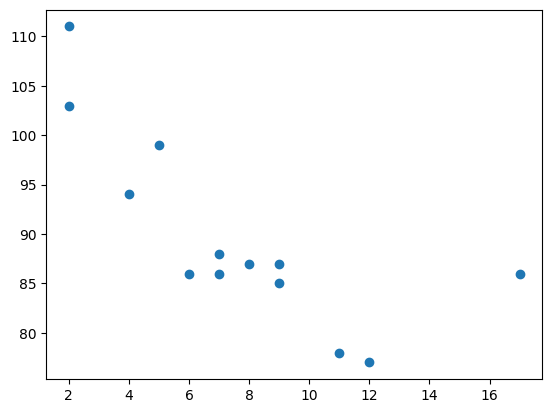

In [3]:
plt.scatter(x, y)

In [4]:
slope, intercept, r, p, std_err = stats.linregress(x, y)

In [5]:
def prediction_function(x):
  return slope * x + intercept

In [6]:
lr_model = list(map(prediction_function, x))

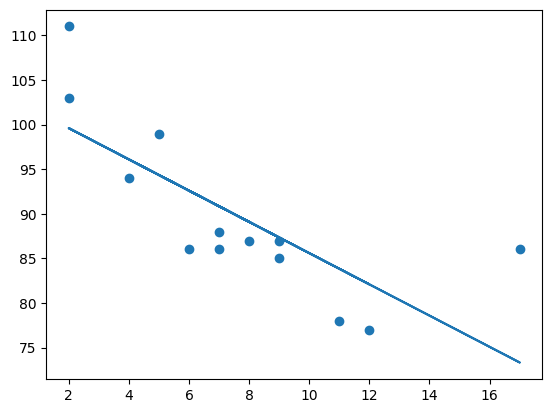

In [7]:
plt.scatter(x, y)
plt.plot(x, lr_model)
plt.show()

In [8]:
print(r)

-0.758591524376155


In [9]:
prediction = prediction_function(2)

print(prediction)

99.60338484179543


#### Polynomial regression

A type of regression analysis that models the relationship between an independent variable and a dependent variable as an n-th degree polynomial.

In [10]:
import numpy
import matplotlib.pyplot as plt

In [11]:
x = [1,2,3,5,6,7,8,9,10,12,13,14,15,16,18,19,21,22]
y = [100,90,80,60,60,55,60,65,70,70,75,76,78,79,90,99,99,100]

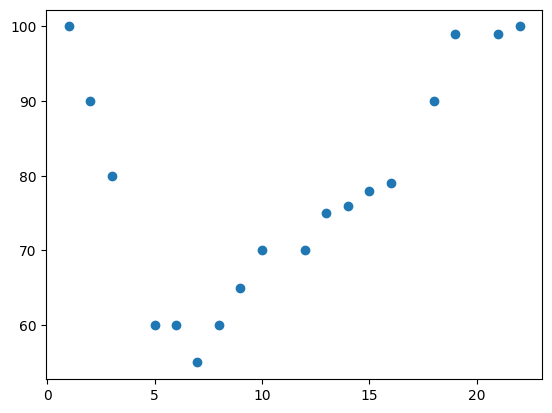

In [12]:
plt.scatter(x, y)

In [13]:
poly_model = numpy.poly1d(numpy.polyfit(x, y, 3))

In [24]:
 poly_line = numpy.linspace(1, 22, 100)

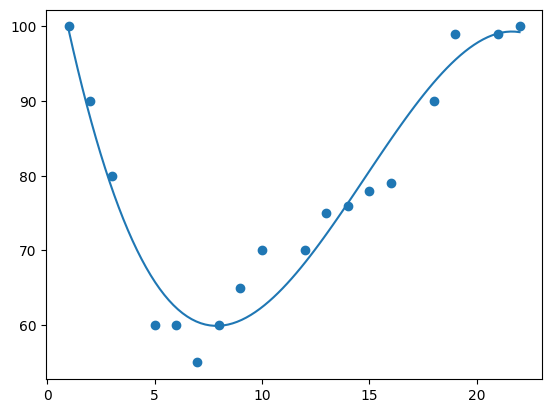

In [25]:
plt.scatter(x, y)
plt.plot(poly_line, poly_model(poly_line))
plt.show()

In [26]:
from sklearn.metrics import r2_score

In [27]:
print(r2_score(y, poly_model(x)))

0.9432150416451026


In [28]:
poly_prediction = poly_model(5)
print(poly_prediction)

65.86970529316687


+ Mean Squared Error (MSE): Measures the average squared difference between actual and predicted values to avoid cancellation of errors.

+ Mean Absolute Error (MAE): Calculate the accuracy of a regression model. MAE measures the average absolute difference between the predicted values and actual values.

+ Root Mean Squared Error (RMSE): Square root of the residuals variance is RMSE. It describes how well the observed data points match the expected values or the model's absolute fit to the data.

+ R-Squared: Indicates how much variation the model explains. Its value is typically between 0 and 1, but it can be negative if the model performs worse than a simple baseline model (e.g., predicting the mean).

+ Adjusted R-square: Measures the proportion of variance explained by the model while adjusting for the number of predictors and penalizing irrelevant features.

#### Practice: English Expressives

The data and the idea are from [Constant et al.](https://www.google.com/url?sa=t&rct=j&q=&esrc=s&source=web&cd=&cad=rja&uact=8&ved=2ahUKEwi8zPWai9L1AhWvs4sKHWqbATIQFnoECAcQAQ&url=https%3A%2F%2Fweb.stanford.edu%2F~cgpotts%2Fpapers%2Fconstant-davis-potts-schwarz-expressives.pdf&usg=AOvVaw3QUEeV5U8r1FKhWne43xn3)

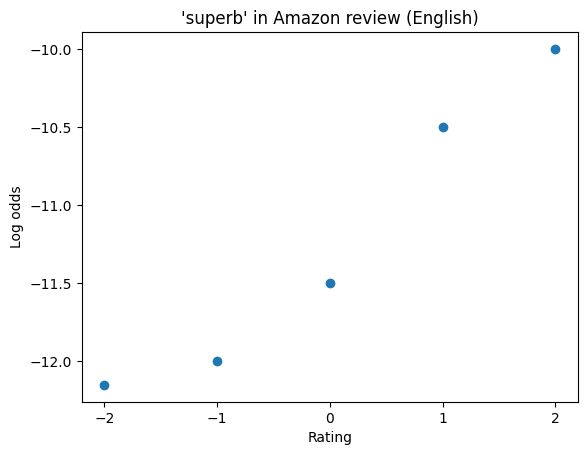

In [42]:
x = [-2,-1,0,1,2]
y = [-12.15,-12,-11.5,-10.5,-10]

plt.scatter(x, y)
plt.xlabel("Rating")
plt.ylabel("Log odds")
plt.title("'superb' in Amazon review (English)")
plt.xticks(x)
plt.show()

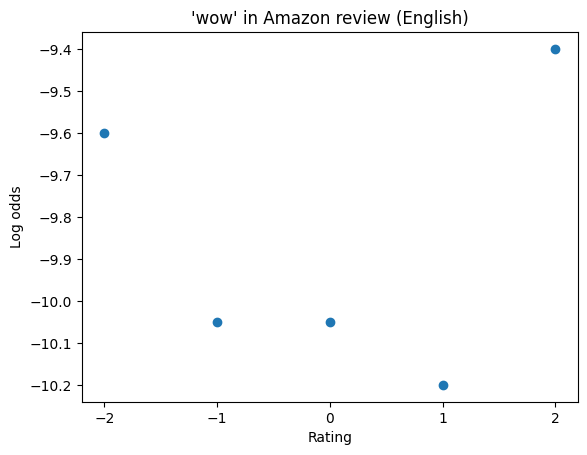

In [43]:
x = [-2,-1,0,1,2]
y = [-9.6,-10.05,-10.05,-10.2,-9.4]

plt.scatter(x, y)
plt.xlabel("Rating")
plt.ylabel("Log odds")
plt.title("'wow' in Amazon review (English)")
plt.xticks(x)
plt.show()

#### Linear regression using ```sklearn```

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [45]:
np.random.seed(0)
x = np.random.rand(100, 1)
y = 2 + 3 * x + np.random.rand(100, 1)

In [46]:
regression_model = LinearRegression()
regression_model.fit(x, y)
y_predicted = regression_model.predict(x)

In [47]:
rmse = mean_squared_error(y, y_predicted)
r2 = r2_score(y, y_predicted)

In [48]:
print('Slope:' ,regression_model.coef_)
print('Intercept:', regression_model.intercept_)
print('Root mean squared error: ', rmse)
print('R2 score: ', r2)

Slope: [[2.93655106]]
Intercept: [2.55808002]
Root mean squared error:  0.07623324582875007
R2 score:  0.9038655568672764


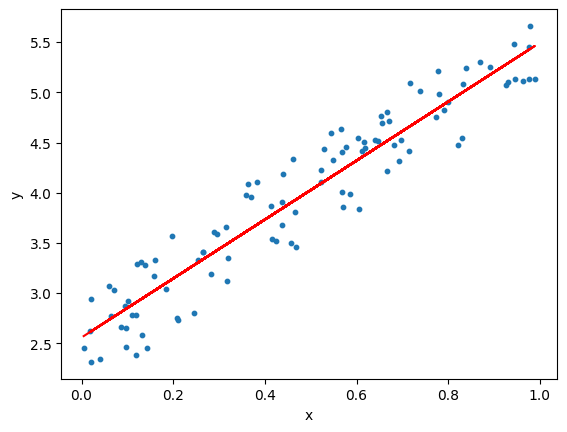

In [49]:
plt.scatter(x, y, s=10)
plt.xlabel('x')
plt.ylabel('y')

plt.plot(x, y_predicted, color='r')
plt.show()

#### Multiple linear regression

[The data](https://www.w3schools.com/python/cars.csv)

In [50]:
import pandas



In [52]:
df = pandas.read_csv("cars.csv")

In [53]:
X = df[['Weight', 'Volume']]
y = df['CO2']

In [54]:
from sklearn import linear_model

In [55]:
regr = linear_model.LinearRegression()
regr.fit(X, y)

LinearRegression()

In [56]:
predictedCO2 = regr.predict([[2300, 1300]])

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [57]:
print(predictedCO2)

[107.2087328]


In [58]:
print(regr.coef_)

[0.00755095 0.00780526]


If the weight changes by 1kg, the CO2 output changes by 0.00755095g, if the volume changes by 1cm3, the output changes by 0.00780526g.

#### Scaling

[The data](https://www.w3schools.com/python/cars2.csv)

In [59]:
from sklearn.preprocessing import StandardScaler

scale = StandardScaler()

df = pandas.read_csv("cars2.csv")

X = df[['Weight', 'Volume']]

scaledX = scale.fit_transform(X)

print(scaledX[:10])

[[-2.10389253 -1.59336644]
 [-0.55407235 -1.07190106]
 [-1.52166278 -1.59336644]
 [-1.78973979 -1.85409913]
 [-0.63784641 -0.28970299]
 [-1.52166278 -1.59336644]
 [-0.76769621 -0.55043568]
 [ 0.3046118  -0.28970299]
 [-0.7551301  -0.28970299]
 [-0.59595938 -0.0289703 ]]


In [60]:
regr = linear_model.LinearRegression()
regr.fit(scaledX, y)

scaled = scale.transform([[2300, 1.3]])

predictedCO2 = regr.predict([scaled[0]])
print(predictedCO2)

[107.2087328]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


#### Train and test

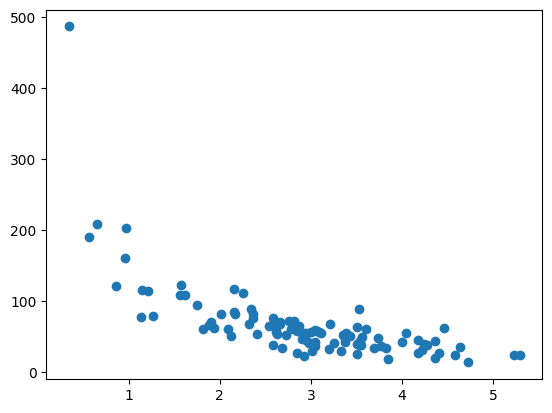

In [61]:
import numpy
import matplotlib.pyplot as plt
numpy.random.seed(2)

x = numpy.random.normal(3, 1, 100)
y = numpy.random.normal(150, 40, 100) / x

plt.scatter(x, y)
plt.show()

In [62]:
train_x = x[:80]
train_y = y[:80]

test_x = x[80:]
test_y = y[80:]

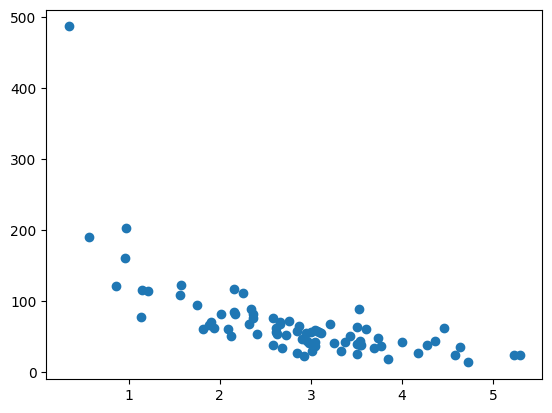

In [63]:
plt.scatter(train_x, train_y)
plt.show()

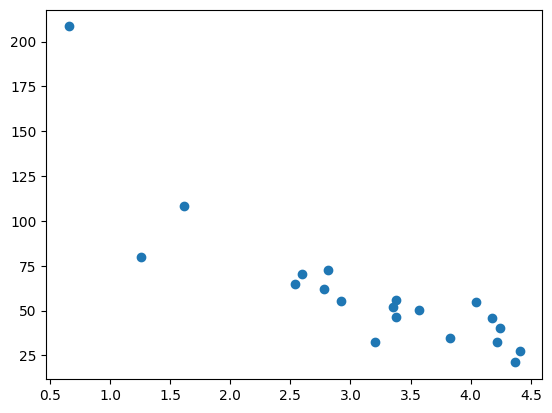

In [64]:
plt.scatter(test_x, test_y)
plt.show()

Пробуем полиномиальную регрессию:

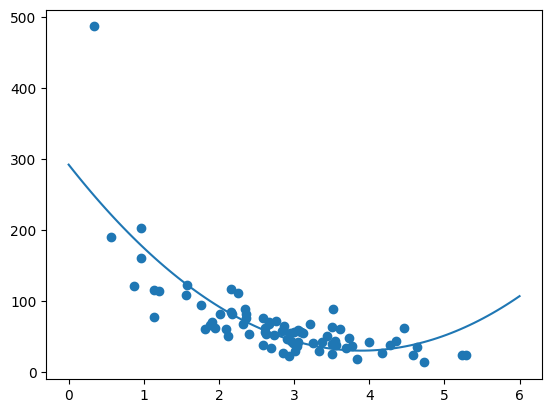

In [66]:
import numpy
import matplotlib.pyplot as plt
numpy.random.seed(2)

x = numpy.random.normal(3, 1, 100)
y = numpy.random.normal(150, 40, 100) / x

train_x = x[:80]
train_y = y[:80]

test_x = x[80:]
test_y = y[80:]

model = numpy.poly1d(numpy.polyfit(train_x, train_y, 2))

line = numpy.linspace(0, 6, 100)

plt.scatter(train_x, train_y)
plt.plot(line, model(line))
plt.show()

In [67]:
r2 = r2_score(train_y, model(train_x))

print(r2)

0.6304398951453632


In [68]:
r2 = r2_score(test_y, model(test_x))

print(r2)

0.7381548349941074


In [69]:
print(model(5))

51.94641639781946
